# Loading Data and Using Gurobi for Portfolio Optimization
## Objective
In this notebook, we will load the preprocessed data (expected returns, covariance matrix, and ticker symbols) saved from Data Preprocessing and Saving for Portfolio Optimization Notebook, and then use Gurobi to solve the Markowitz Mean-Variance Optimization problem.
## Libraries Used
* `numpy`: For numerical operations.
* `pandas`: For data structures and manipulation.
* `gurobipy`: The optimization solver.
* `pickle`: To load the saved Python objects.
* `os`: To check if the data files exist.
* `matplotlib.pyplot` & `seaborn`: For visualization.

## Imports and Gurobi Function
This cell imports necessary libraries and defines the Gurobi optimization function.

In [ ]:
pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 63.8 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import pickle
import os # To check for file existence
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For enhanced plotting

In [7]:
# --- Paste the corrected optimize_portfolio_gurobi_final function here ---
def optimize_portfolio_gurobi_final(expected_returns, covariance_matrix, target_return, solver_params=None):
    """
    Solves the Markowitz Mean-Variance Portfolio Optimization problem using Gurobi.
    Corrected quadratic objective and constraint formulation.

    Args:
        expected_returns (np.ndarray): Array of mean returns for each asset.
        covariance_matrix (np.ndarray): Covariance matrix of asset returns.
        target_return (float): The minimum desired portfolio return.
        solver_params (dict, optional): Dictionary of Gurobi parameters. Defaults to None.

    Returns:
        tuple: A tuple containing:
            - weights (np.ndarray): Optimal portfolio weights for each asset.
            - min_variance (float): The minimum portfolio variance achieved.
            - model (gp.Model): The Gurobi model object.
            - solution_status (str): Description of the optimization result.
    """
    num_assets = len(expected_returns)
    
    model = gp.Model("PortfolioOptimization")
    x = model.addVars(num_assets, name="x")

    # Objective: Minimize portfolio variance (x' * Sigma * x)
    quad_expr = gp.LinExpr()
    for i in range(num_assets):
        for j in range(num_assets):
            quad_expr += covariance_matrix[i, j] * x[i] * x[j]
    
    model.setObjective(quad_expr, GRB.MINIMIZE)

    # Constraint 1: Target Expected Return (mu' * x >= target_return)
    return_constraint_expr = gp.LinExpr()
    for i in range(num_assets):
        return_constraint_expr += expected_returns[i] * x[i]
        
    model.addConstr(return_constraint_expr >= target_return, "TargetReturn")

    # Constraint 2: Full Investment (sum(x) == 1)
    model.addConstr(x.sum() == 1, "FullInvestment")

    # Constraint 3: No Short Selling (x_i >= 0)
    for i in range(num_assets):
        x[i].setAttr("LB", 0.0)

    # Apply solver parameters if provided
    if solver_params:
        for param, value in solver_params.items():
            model.setParam(param, value)

    # Solve the model
    try:
        model.optimize()
    except gp.GurobiError as e:
        print(f"Gurobi Error code {e.errno}: {e.message}")
        return None, None, model, "Gurobi Error"
    except Exception as e:
        print(f"An unexpected error occurred during Gurobi optimization: {e}")
        return None, None, model, "Optimization Exception"

    # Process results
    if model.status == gp.GRB.OPTIMAL:
        weights = np.array([v.x for v in model.getVars()])
        min_variance = model.ObjVal
        solution_status = "Optimal Solution Found"
        return weights, min_variance, model, solution_status
    elif model.status == gp.GRB.INFEASIBLE:
        return None, None, model, "Infeasible"
    elif model.status == gp.GRB.UNBOUNDED:
        return None, None, model, "Unbounded"
    else:
        return None, None, model, f"Optimization ended with status {model.status}"

print("Libraries imported and Gurobi function defined.")

Libraries imported and Gurobi function defined.


## Load the Preprocessed Data
This cell loads the saved data from the files created in Notebook 1.

In [8]:
# Define the paths to the saved data files (CHANGE THIS FOR YOUR CODE!)
base_path = r"C:\Users\yaren\Desktop\IEOR 4004 - Optimization\SPRING 2026\Lectures\Case Study Markowitz Portfolio\processed_data"

returns_file = os.path.join(base_path, "expected_returns.pkl")
cov_matrix_file = os.path.join(base_path, "covariance_matrix.pkl")
tickers_file = os.path.join(base_path, "successful_tickers.pkl")

# Check if the necessary files exist before attempting to load
if (os.path.exists(returns_file) and
    os.path.exists(cov_matrix_file) and
    os.path.exists(tickers_file)):

    print("--- Loading Preprocessed Data ---")
    try:
        with open(returns_file, 'rb') as f:
            expected_returns_loaded = pickle.load(f)
        print(f"Loaded expected returns: Shape {expected_returns_loaded.shape}")

        with open(cov_matrix_file, 'rb') as f:
            covariance_matrix_loaded = pickle.load(f)
        print(f"Loaded covariance matrix: Shape {covariance_matrix_loaded.shape}")

        with open(tickers_file, 'rb') as f:
            successful_tickers_loaded = pickle.load(f)
        print(f"Loaded successful tickers list: Count {len(successful_tickers_loaded)}")
        if successful_tickers_loaded:
            print(f"Sample tickers: {successful_tickers_loaded[:5]}...")

        data_loaded_successfully = True

    except Exception as e:
        print(f"\nAn error occurred while loading the data: {e}")
        print("Please ensure Notebook 1 ran successfully and saved the files in the 'processed_data' directory.")
        data_loaded_successfully = False
        expected_returns_loaded, covariance_matrix_loaded, successful_tickers_loaded = None, None, []

else:
    print("\nError: Data files not found. Please ensure Notebook 1 ran successfully and created the 'processed_data' directory and its files.")
    data_loaded_successfully = False
    expected_returns_loaded, covariance_matrix_loaded, successful_tickers_loaded = None, None, []

--- Loading Preprocessed Data ---
Loaded expected returns: Shape (99,)
Loaded covariance matrix: Shape (99, 99)
Loaded successful tickers list: Count 99
Sample tickers: ['JD', 'CSCO', 'BAC', 'AEP', 'NVDA']...


## Run Optimization with Loaded Data
Now, we use the loaded data and the Gurobi function to find the optimal portfolio.

In [9]:
if data_loaded_successfully:
    print("\n--- Proceeding with Gurobi Optimization ---")

    # --- Define Target Return ---
    # We'll use a fixed target return for demonstration, e.g., 25% or 0.25.
    # You could also dynamically set this based on loaded data, as shown before.
    target_return_for_optimization_loaded = 0.25 # Set a fixed target return of 25%

    # Ensure the target is reasonable based on loaded data (optional but good practice)
    if expected_returns_loaded is not None and len(successful_tickers_loaded) > 0:
        min_ind_ret_loaded = np.min(expected_returns_loaded)
        max_ind_ret_loaded = np.max(expected_returns_loaded)

        # Adjust target if it's outside reasonable bounds
        target_return_for_optimization_loaded = max(min_ind_ret_loaded * 1.05, target_return_for_optimization_loaded)
        target_return_for_optimization_loaded = min(max_ind_ret_loaded * 0.95, target_return_for_optimization_loaded)

        print(f"Number of tickers for optimization: {len(successful_tickers_loaded)}")
        print(f"Min Individual Expected Return: {min_ind_ret_loaded:.6f}")
        print(f"Max Individual Expected Return: {max_ind_ret_loaded:.6f}")
        print(f"Chosen Target Portfolio Return: {target_return_for_optimization_loaded:.6f}")
    else:
        print("Loaded data is invalid. Cannot set a meaningful target return.")
        # You might want to exit or handle this case if data isn't loaded properly.

    # --- Run the Optimization ---
    # Optional: You can define Gurobi solver parameters here if needed
    # Example: solver_parameters = {"MIPGap": 1e-5, "TimeLimit": 60}
    solver_parameters = {} # Using default parameters

    print("\nRunning Gurobi optimizer...")
    optimal_weights, min_variance, portfolio_model, status = optimize_portfolio_gurobi_final(
        expected_returns_loaded,
        covariance_matrix_loaded,
        target_return_for_optimization_loaded,
        solver_params=solver_parameters
    )

    # --- Display Results ---
    if status == "Optimal Solution Found":
        print("\n--- Optimization Results ---")
        print(f"Status: {status}")
        print(f"Minimum Portfolio Variance: {min_variance:.8f}")
        print(f"Achieved Expected Return: {np.dot(expected_returns_loaded, optimal_weights):.8f}")

        print("\n--- Top 10 Holdings by Weight ---")
        weighted_stocks = sorted(zip(optimal_weights, successful_tickers_loaded), key=lambda x: x[0], reverse=True)

        count = 0
        for weight, name in weighted_stocks:
            if weight > 1e-6 and count < 10: # Display significant weights only, up to top 10
                print(f"{name}: {weight:.4f}")
                count += 1

        # Verification checks
        portfolio_return_actual = np.dot(expected_returns_loaded, optimal_weights)
        portfolio_variance_actual = optimal_weights.T @ covariance_matrix_loaded @ optimal_weights
        print(f"\nVerification:")
        print(f"Sum of weights: {np.sum(optimal_weights):.6f}")
        print(f"Achieved portfolio return: {portfolio_return_actual:.8f} (Target: >= {target_return_for_optimization_loaded:.8f})")
        print(f"Calculated portfolio variance: {portfolio_variance_actual:.8f} (Matches objective: {min_variance:.8f})")

    else:
        print(f"\nOptimization did not find an optimal solution. Status: {status}")
        print("Possible reasons include infeasible target return, issues with input data, or Gurobi solver problems.")
        print("Consider adjusting the target return or re-checking your input data.")
else:
    print("\nSkipping optimization as data loading failed.")


--- Proceeding with Gurobi Optimization ---
Number of tickers for optimization: 99
Min Individual Expected Return: -0.290099
Max Individual Expected Return: 0.871522
Chosen Target Portfolio Return: 0.250000

Running Gurobi optimizer...
Set parameter Username
Academic license - for non-commercial use only - expires 2026-09-08
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 2 rows, 99 columns and 198 nonzeros
Model fingerprint: 0xb6f1bf42
Model has 4950 quadratic objective terms
Coefficient statistics:
  Matrix range     [3e-03, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [6e-05, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e-01, 1e+00]
Presolve time: 0.06s
Presolved: 2 rows, 99 columns, 198 nonzeros
Presolved model has 4950 quadratic objective terms
Ordering time:

## Visualizing the Results (Efficient Frontier)
This is where we bring the concept of the efficient frontier to life, showing the set of optimal portfolios and where our specific optimized portfolio fits in.

### Explanation of the Efficient Frontier Calculation
* The Process: To visualize the efficient frontier, we don't just run the optimization once. We need to simulate finding the lowest-risk portfolio for many different target return levels.
* Generating Targets: We create a range of potential target returns, from the minimum expected return of any single stock in our dataset up to a bit beyond the maximum.
* Multiple Optimizations: For each target return in our range, we run the Gurobi optimization. This gives us a pair of values:
The minimum variance (risk) for that specific target return.
The actual achieved return (which will be ≥ the target).
* Plotting: We then plot these pairs of (risk, return) values. The resulting curve represents the efficient frontier. The red dot shows where our specific portfolio (which targeted 10% but achieved 20.53%) sits in relation to all other possible efficient portfolios.


In [10]:
# --- Efficient Frontier Calculation and Plotting ---

# Check if we successfully loaded data and ran the initial optimization
if data_loaded_successfully and status == "Optimal Solution Found":
    print("\n--- Generating Efficient Frontier Data ---")

    # We need to run the optimization for a range of target returns
    # to trace out the efficient frontier.

    min_ind_ret = np.min(expected_returns_loaded)
    max_ind_ret = np.max(expected_returns_loaded)

    # Create a range of target returns. Let's create 30 points for a smooth curve.
    # We aim for targets between the min and max individual expected returns.
    # We add a small buffer beyond the max individual return to see the curve's shape.
    target_returns_for_frontier = np.linspace(min_ind_ret, max_ind_ret * 1.1, 30)

    # Store results for plotting
    frontier_variances = []
    frontier_achieved_returns = []
    frontier_std_devs = [] # Portfolio Volatility for the X-axis

    # Gurobi parameters for potentially faster frontier generation
    # We can set a time limit or MIP gap if needed, but defaults are often fine.
    solver_params_frontier = {'TimeLimit': 10} # Limit each frontier point calculation to 10 seconds

    print(f"Calculating {len(target_returns_for_frontier)} points for the efficient frontier...")

    for i, target_ret in enumerate(target_returns_for_frontier):
        # Adjust target_ret to ensure it's feasible and not trivial.
        # Avoid targets too close to the absolute minimum or maximum if they cause issues.
        if target_ret < min_ind_ret * 1.05:
             target_ret = min_ind_ret * 1.05
        # Ensure target isn't excessively high if max individual return is already very high
        if max_ind_ret > 0: # Only adjust if max return is positive
            target_ret = min(max_ind_ret * 0.95, target_ret)

        # Skip if the target is outside a reasonable range after adjustments
        if target_ret < min_ind_ret or target_ret > max_ind_ret * 1.1:
             continue

        # Run the optimization for this specific target return
        weights_f, variance_f, model_f, status_f = optimize_portfolio_gurobi_final(
            expected_returns_loaded,
            covariance_matrix_loaded,
            target_ret,
            solver_params=solver_params_frontier
        )

        # If an optimal solution was found for this target return
        if status_f == "Optimal Solution Found":
            achieved_ret_f = np.dot(expected_returns_loaded, weights_f) # The actual return achieved
            std_dev_f = np.sqrt(variance_f) # Convert variance to standard deviation (volatility)

            frontier_variances.append(variance_f)
            frontier_achieved_returns.append(achieved_ret_f)
            frontier_std_devs.append(std_dev_f)
            # print(f"  Point {i+1}/{len(target_returns_for_frontier)}: Target={target_ret:.4f}, AchievedRet={achieved_ret_f:.4f}, Variance={variance_f:.6f}") # Optional verbose print
        # else:
            # print(f"  Point {i+1}/{len(target_returns_for_frontier)}: Could not find optimal for target {target_ret:.4f} (Status: {status_f})") # Optional verbose print

    # Convert lists to numpy arrays for easier plotting
    frontier_variances = np.array(frontier_variances)
    frontier_achieved_returns = np.array(frontier_achieved_returns)
    frontier_std_devs = np.array(frontier_std_devs)

else:
    print("\nCannot generate Efficient Frontier: Data preparation or initial optimization failed.")


--- Generating Efficient Frontier Data ---
Calculating 30 points for the efficient frontier...
Set parameter TimeLimit to value 10
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 2 rows, 99 columns and 198 nonzeros
Model fingerprint: 0xfa6f7cf4
Model has 4950 quadratic objective terms
Coefficient statistics:
  Matrix range     [3e-03, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [6e-05, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e-01, 1e+00]
Presolve time: 0.01s
Presolved: 2 rows, 99 columns, 198 nonzeros
Presolved model has 4950 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 98
 AA' NZ     : 4.950e+03
 Factor NZ  : 5.050e+03
 Factor Ops : 3.384e+05 (less than 1 second per iteration)
 Threads    : 1

                  Objective

   6   5.20193861e-02 -6.30078644e-02  3.59e-11 2.78e-17  1.15e-03     0s
   7   1.95880822e-02 -2.03641061e-02  1.67e-16 4.16e-17  4.00e-04     0s
   8   1.17244748e-02  5.20585846e-03  8.33e-17 1.25e-16  6.52e-05     0s
   9   9.95720806e-03  5.40357162e-03  2.36e-16 1.91e-17  4.55e-05     0s
  10   9.15753392e-03  8.61380255e-03  1.11e-16 1.73e-17  5.44e-06     0s
  11   8.87731397e-03  8.79883970e-03  3.40e-16 1.91e-17  7.85e-07     0s
  12   8.83160916e-03  8.82334793e-03  1.84e-16 3.38e-17  8.26e-08     0s
  13   8.82647360e-03  8.82635672e-03  1.33e-15 2.30e-17  1.17e-09     0s
  14   8.82638929e-03  8.82638639e-03  2.68e-14 3.17e-17  2.91e-11     0s

Barrier solved model in 14 iterations and 0.06 seconds (0.01 work units)
Optimal objective 8.82638929e-03

Set parameter TimeLimit to value 10
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical process

 Factor NZ  : 5.050e+03
 Factor Ops : 3.384e+05 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   3.97214406e+05 -3.97214406e+05  5.43e+04 1.84e-03  9.99e+05     0s
   1   4.46790856e+05 -4.47169194e+05  4.50e+03 1.52e-04  9.54e+04     0s
   2   2.01957863e+04 -2.07311782e+04  2.19e+02 7.42e-06  5.11e+03     0s
   3   9.60383273e-01 -6.06768524e+02  4.53e-01 1.53e-08  1.67e+01     0s
   4   1.47630958e-01 -2.51922217e+02  4.53e-07 1.53e-14  2.52e+00     0s
   5   1.46974098e-01 -4.34984413e-01  5.45e-10 2.78e-17  5.82e-03     0s
   6   5.34396581e-02 -6.49332790e-02  3.52e-11 1.39e-17  1.18e-03     0s
   7   1.98322827e-02 -2.14998080e-02  1.94e-16 6.94e-17  4.13e-04     0s
   8   1.17329084e-02  5.21281690e-03  1.67e-16 2.78e-17  6.52e-05     0s
   9   9.98055929e-03  5.21740975e-03  1.67e-16 2.08e-17  4.76e-05     0s
  10   9.17925616e-03  8.59157836e


CPU model: 13th Gen Intel(R) Core(TM) i9-13900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 2 rows, 99 columns and 198 nonzeros
Model fingerprint: 0x292f0a23
Model has 4950 quadratic objective terms
Coefficient statistics:
  Matrix range     [3e-03, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [6e-05, 2e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-01, 1e+00]
Presolve time: 0.01s
Presolved: 2 rows, 99 columns, 198 nonzeros
Presolved model has 4950 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 98
 AA' NZ     : 4.950e+03
 Factor NZ  : 5.050e+03
 Factor Ops : 3.384e+05 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   3.97214815e+05 -3.97214815e+05  5.42e+04 1.84e-03  9.99e+05     0s
   1   4.4679515

   8   1.39989102e-02  7.51486508e-03  2.22e-16 1.27e-16  6.48e-05     0s
   9   1.18269616e-02  8.79116741e-03  5.97e-16 3.82e-17  3.04e-05     0s
  10   1.10045603e-02  1.06660221e-02  8.19e-16 3.47e-17  3.39e-06     0s
  11   1.07912590e-02  1.07520561e-02  4.22e-15 2.97e-17  3.92e-07     0s
  12   1.07614097e-02  1.07609374e-02  1.09e-14 2.60e-17  4.72e-09     0s
  13   1.07610154e-02  1.07610088e-02  8.22e-15 2.60e-17  6.58e-11     0s

Barrier solved model in 13 iterations and 0.06 seconds (0.01 work units)
Optimal objective 1.07610154e-02

Set parameter TimeLimit to value 10
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: 13th Gen Intel(R) Core(TM) i9-13900H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Optimize a model with 2 rows, 99 columns and 198 nonzeros
Model fingerprint: 0x3c8703f1
Model has 4950 quadratic objective terms
Coefficient statistics:
  Matrix range     [3e-03, 1e+00]
  Obje

   3   1.00933868e+00 -5.34192383e+02  4.58e-01 1.55e-08  1.61e+01     0s
   4   1.92064884e-01 -2.21564961e+02  5.49e-03 1.86e-10  2.28e+00     0s
   5   1.89254764e-01 -6.43756393e-01  1.23e-05 4.15e-13  8.33e-03     0s
   6   1.10444244e-01 -2.72839195e-02  1.11e-06 3.74e-14  1.38e-03     0s
   7   5.92834130e-02  1.20696969e-02  1.11e-12 1.39e-17  4.72e-04     0s
   8   4.29776366e-02  2.51326651e-02  4.72e-16 3.89e-16  1.78e-04     0s
   9   3.79333517e-02  3.49599239e-02  6.74e-15 3.11e-16  2.97e-05     0s
  10   3.61259710e-02  3.58989154e-02  5.38e-15 4.39e-16  2.27e-06     0s
  11   3.59383104e-02  3.59360466e-02  2.70e-14 4.23e-16  2.26e-08     0s
  12   3.59368904e-02  3.59367615e-02  4.06e-13 3.07e-16  1.29e-09     0s
  13   3.59367874e-02  3.59367845e-02  1.59e-12 2.78e-16  2.89e-11     0s

Barrier solved model in 13 iterations and 0.06 seconds (0.01 work units)
Optimal objective 3.59367874e-02

Set parameter TimeLimit to value 10
Gurobi Optimizer version 10.0.3 build v10.

   1   4.46806975e+05 -4.47091785e+05  4.50e+03 1.52e-04  9.54e+04     0s
   2   2.02055464e+04 -2.06359568e+04  2.19e+02 7.40e-06  5.11e+03     0s
   3   1.02453878e+00 -5.07507945e+02  4.60e-01 1.55e-08  1.58e+01     0s
   4   2.90365385e-01 -1.44937308e+02  1.88e-02 6.34e-10  1.78e+00     0s
   5   2.51142357e-01 -1.27574372e+01  2.39e-04 8.05e-12  1.30e-01     0s
   6   2.27895965e-01  9.10017971e-03  1.22e-06 4.12e-14  2.19e-03     0s
   7   1.63429069e-01  6.79072738e-02  1.36e-12 2.78e-17  9.55e-04     0s
   8   1.36908235e-01  1.22428500e-01  9.05e-15 1.17e-15  1.45e-04     0s
   9   1.28288312e-01  1.26549502e-01  3.33e-14 5.55e-16  1.74e-05     0s
  10   1.26788775e-01  1.26774669e-01  1.23e-14 3.89e-16  1.41e-07     0s
  11   1.26775460e-01  1.26775445e-01  1.80e-14 5.90e-16  1.43e-10     0s
  12   1.26775446e-01  1.26775446e-01  2.64e-14 8.19e-16  1.43e-13     0s

Barrier solved model in 12 iterations and 0.06 seconds (0.01 work units)
Optimal objective 1.26775446e-01

Set 

 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   3.97216346e+05 -3.97216346e+05  5.42e+04 1.83e-03  9.99e+05     0s
   1   4.46811235e+05 -4.47071319e+05  4.50e+03 1.52e-04  9.54e+04     0s
   2   2.02081291e+04 -2.06107423e+04  2.19e+02 7.40e-06  5.11e+03     0s
   3   1.04004818e+00 -4.80898333e+02  4.59e-01 1.55e-08  1.56e+01     0s
   4   4.90266824e-01 -5.35850795e+01  7.40e-02 2.49e-09  3.15e+00     0s
   5   3.37922187e-01 -4.91873599e+01  7.40e-08 2.50e-15  4.95e-01     0s
   6   3.37911433e-01  1.61437543e-01  1.90e-10 8.05e-13  1.76e-03     0s
   7   3.24737906e-01  2.51490407e-01  1.51e-13 2.66e-15  7.32e-04     0s
   8   3.11663197e-01  2.91152206e-01  2.10e-13 2.66e-15  2.05e-04     0s
   9   3.02826048e-01  2.97228200e-01  2.41e-13 1.89e-15  5.60e-05     0s
  10   2.99123562e-01  2.98132445e-01  4.47e-13 1.20e-15  9.91e-06     0s
  11   2.98382731e-01  2.98185814e-01  3.08

## Markowitz Efficient Frontier

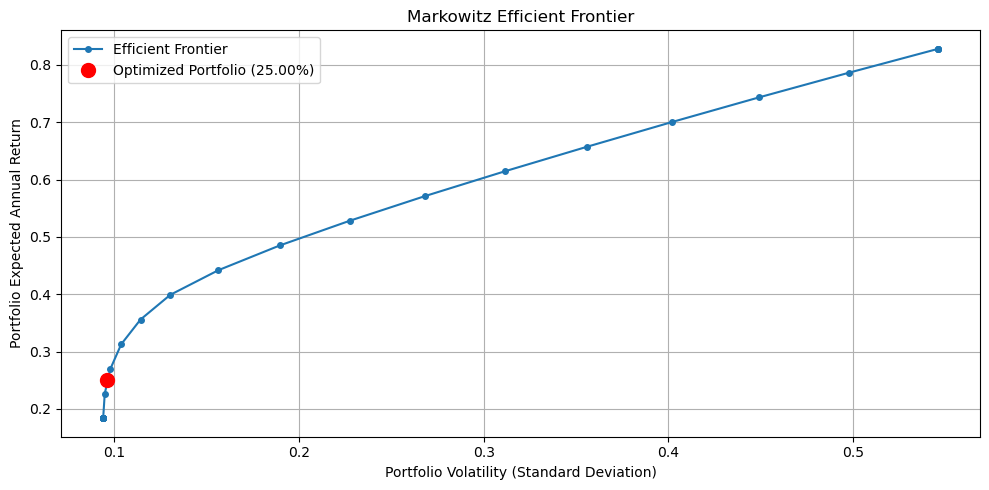

In [11]:
# --- Plotting the Results ---
plt.figure(figsize=(10, 5))

# Plot the efficient frontier curve
if len(frontier_std_devs) > 0:
    plt.plot(frontier_std_devs, frontier_achieved_returns, 'o-', label='Efficient Frontier', markersize=4)
else:
    print("No points were generated for the efficient frontier. Check data and target ranges.")

# Mark our specific optimized portfolio
optimal_portfolio_return = np.dot(expected_returns_loaded, optimal_weights)
optimal_portfolio_std_dev = np.sqrt(min_variance)
plt.plot(optimal_portfolio_std_dev, optimal_portfolio_return, 'ro', markersize=10, label=f'Optimized Portfolio ({optimal_portfolio_return:.2%})')

# Add plot labels and title
plt.title('Markowitz Efficient Frontier')
plt.xlabel('Portfolio Volatility (Standard Deviation)')
plt.ylabel('Portfolio Expected Annual Return')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()